In [1]:
# egor zernin
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

plt.style.use('ggplot')
%matplotlib inline

print("Библиотеки загружены")
df = pd.read_csv('titanic.csv')
print("Данные загружены! Размер:", df.shape)

Библиотеки загружены
Данные загружены! Размер: (891, 12)


In [2]:
print("Первые 5 строк:")
print(df.head())
print("\nПоследние 5 строк:")
print(df.tail())
print("\nВсего строк:", df.shape[0], "столбцов:", df.shape[1])

Первые 5 строк:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N

In [3]:
print("Информация о данных:")
print(df.info())
print("\nСтатистика по числам:")
print(df.describe())
print("\nСтатистика по текстовым колонкам:")
print(df.describe(include='object'))

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Статистика по числам:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118 

In [4]:
print("Пропуски в каждом столбце:")
print(df.isnull().sum())
print("\nВсего пропусков:", df.isnull().sum().sum())
print("\nДубликаты:", df.duplicated().sum())

Пропуски в каждом столбце:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Всего пропусков: 866

Дубликаты: 0


In [5]:
# Процент пропусков
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Процент пропусков:")
print(missing_percent[missing_percent > 0])

Процент пропусков:
Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


In [6]:
# Создаём копию для очистки
df_clean = df.copy()

# Заполняем Age медианой (обоснование: возраст распределён неравномерно, медиана устойчива к выбросам)
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)
print(f"Age заполнен медианой: {median_age}")

# Заполняем Embarked модой (самое частое значение)
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)
print(f"Embarked заполнен модой: {mode_embarked}")

# Cabin удаляем (слишком много пропусков)
df_clean.drop('Cabin', axis=1, inplace=True)
print("Cabin удалён (более 70% пропусков)")

print("\nПропуски после очистки:")
print(df_clean.isnull().sum())

Age заполнен медианой: 28.0
Embarked заполнен модой: S
Cabin удалён (более 70% пропусков)

Пропуски после очистки:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [7]:
# Для числовых колонок
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols:
    print(f"\nКолонка: {col}")
    print(f"Min: {df_clean[col].min()}")
    print(f"Max: {df_clean[col].max()}")
    print(f"Mean: {df_clean[col].mean():.2f}")
    print(f"Median: {df_clean[col].median()}")
    print(f"Mode: {df_clean[col].mode()[0]}")


Колонка: PassengerId
Min: 1
Max: 891
Mean: 446.00
Median: 446.0
Mode: 1

Колонка: Survived
Min: 0
Max: 1
Mean: 0.38
Median: 0.0
Mode: 0

Колонка: Pclass
Min: 1
Max: 3
Mean: 2.31
Median: 3.0
Mode: 3

Колонка: Age
Min: 0.42
Max: 80.0
Mean: 29.36
Median: 28.0
Mode: 28.0

Колонка: SibSp
Min: 0
Max: 8
Mean: 0.52
Median: 0.0
Mode: 0

Колонка: Parch
Min: 0
Max: 6
Mean: 0.38
Median: 0.0
Mode: 0

Колонка: Fare
Min: 0.0
Max: 512.3292
Mean: 32.20
Median: 14.4542
Mode: 8.05


In [8]:
print("Перцентили для Age и Fare:")
for col in ['Age', 'Fare']:
    print(f"\n{col}:")
    for q in [0.05, 0.25, 0.5, 0.75, 0.95]:
        print(f"  {q*100:.0f}%: {df_clean[col].quantile(q):.2f}")

# Дисперсия, асимметрия, эксцесс
print("\nПродвинутая статистика:")
for col in ['Age', 'Fare']:
    var = df_clean[col].var()
    skew = df_clean[col].skew()
    kurt = df_clean[col].kurtosis()
    print(f"\n{col}:")
    print(f"  Variance: {var:.2f}")
    print(f"  Skewness: {skew:.2f}")  # >1 сильно скошено вправо
    print(f"  Kurtosis: {kurt:.2f}")  # >3 острый пик, <3 плоский

Перцентили для Age и Fare:

Age:
  5%: 6.00
  25%: 22.00
  50%: 28.00
  75%: 35.00
  95%: 54.00

Fare:
  5%: 7.22
  25%: 7.91
  50%: 14.45
  75%: 31.00
  95%: 112.08

Продвинутая статистика:

Age:
  Variance: 169.51
  Skewness: 0.51
  Kurtosis: 0.99

Fare:
  Variance: 2469.44
  Skewness: 4.79
  Kurtosis: 33.40


In [9]:
df_encoded = df_clean.copy()

# One-Hot Encoding для пола и порта посадки
df_encoded = pd.get_dummies(df_encoded, columns=['Sex', 'Embarked'], prefix=['Sex', 'Embarked'])

print("После One-Hot Encoding:")
print(df_encoded.head())
print("\nНовые колонки:", list(df_encoded.columns))

После One-Hot Encoding:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare  Sex_female  Sex_male  Embarked_C  Embarked_Q  \
0         A/5 21171   7.2500       False      True       False       False   
1          PC 17599  71.2833        True     False        True       False   
2  STON/O2. 3101282   7.9250        True     False       False      

In [10]:
df_feat = df_encoded.copy()

# 1. Размер семьи (SibSp + Parch + сам пассажир)
df_feat['FamilySize'] = df_feat['SibSp'] + df_feat['Parch'] + 1

# 2. Одинокий ли пассажир
df_feat['IsAlone'] = (df_feat['FamilySize'] == 1).astype(int)

# 3. Возрастная группа
bins = [0, 12, 18, 35, 50, 80]
labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
df_feat['AgeGroup'] = pd.cut(df_feat['Age'], bins=bins, labels=labels)

# One-Hot для возрастной группы
df_feat = pd.get_dummies(df_feat, columns=['AgeGroup'], prefix='Age')

print("Новые признаки созданы:")
print(df_feat[['FamilySize', 'IsAlone']].head())
print(df_feat[[col for col in df_feat.columns if 'Age_' in col]].head())

Новые признаки созданы:
   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1
   Age_Child  Age_Teen  Age_YoungAdult  Age_Adult  Age_Senior
0      False     False            True      False       False
1      False     False           False       True       False
2      False     False            True      False       False
3      False     False            True      False       False
4      False     False            True      False       False


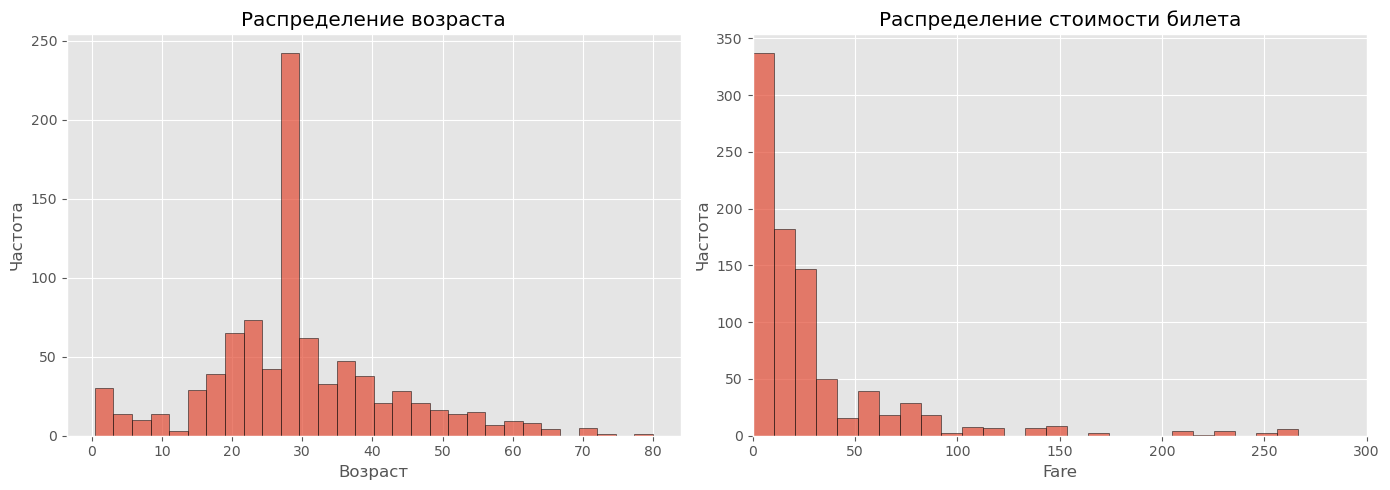

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df_clean['Age'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.hist(df_clean['Fare'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение стоимости билета')
plt.xlabel('Fare')
plt.ylabel('Частота')
plt.xlim(0, 300)  # обрежем хвост для наглядности

plt.tight_layout()
plt.show()

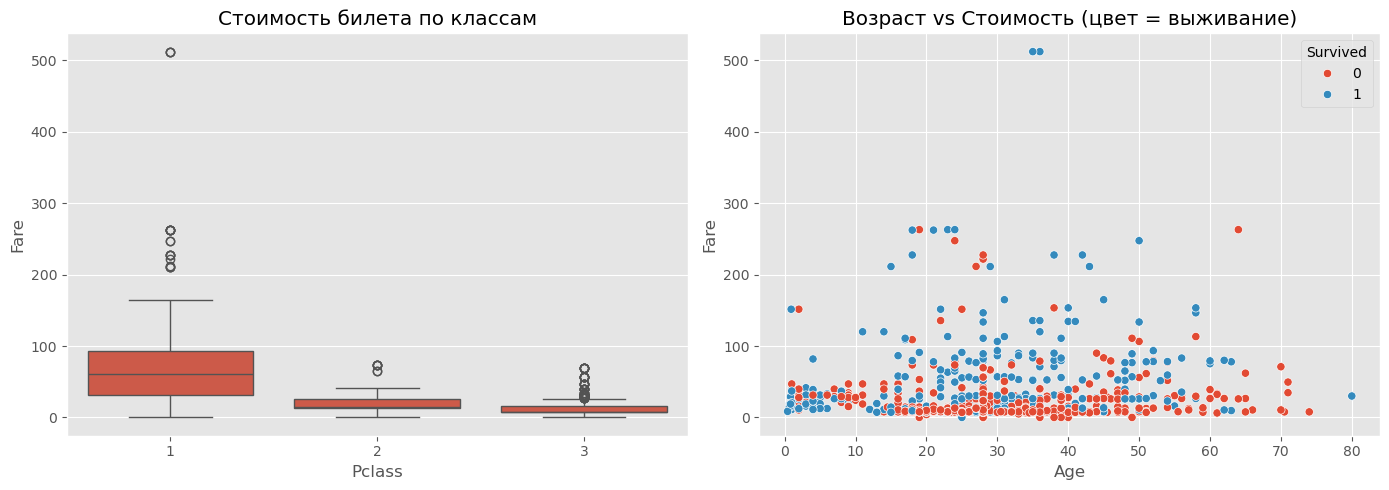

In [12]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean, x='Pclass', y='Fare')
plt.title('Стоимость билета по классам')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x='Age', y='Fare', hue='Survived')
plt.title('Возраст vs Стоимость (цвет = выживание)')

plt.tight_layout()
plt.show()

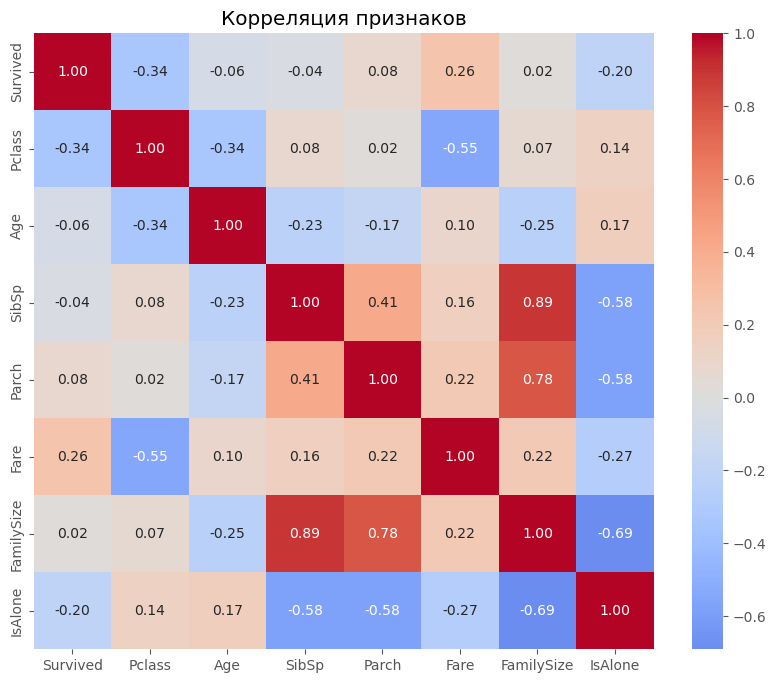

Сильные корреляции с Survived:
Survived    1.000000
Fare        0.257307
IsAlone    -0.203367
Pclass     -0.338481
Name: Survived, dtype: float64


In [13]:
plt.figure(figsize=(10, 8))
corr_matrix = df_feat[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 
                       'FamilySize', 'IsAlone']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

# Вывод
print("Сильные корреляции с Survived:")
corr_with_target = corr_matrix['Survived'].sort_values(ascending=False)
print(corr_with_target[abs(corr_with_target) > 0.1])

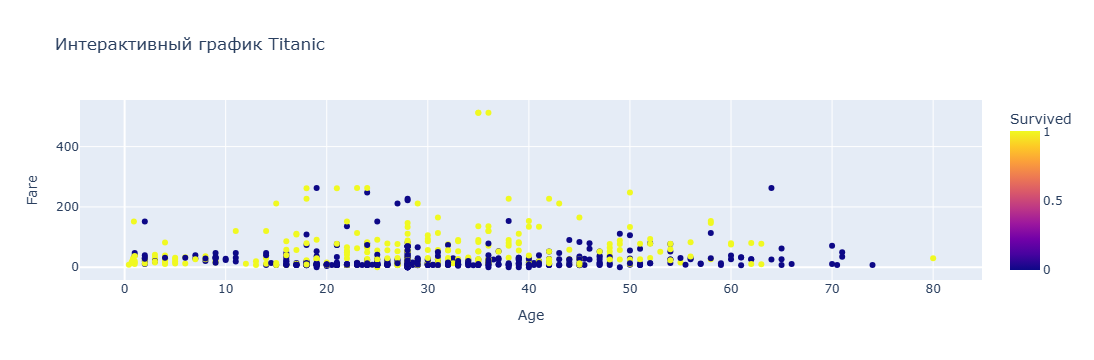

In [14]:
fig = px.scatter(df_clean, x='Age', y='Fare', color='Survived', 
                 hover_data=['Pclass', 'Sex'],
                 title='Интерактивный график Titanic')
fig.show()